# Assignment 3 - ANOVA

5PAM2024 - Statistical Modelling

Name Surname Student ID

---

A randomised controlled trial was conducted to evaluate the efficacy of two novel pharmaceutical compounds (Drug A, Drug B) against a Placebo Control. To determine the most effective delivery method, two administration strategies (Strategy 1, Strategy 2) were employed across all three groups. Efficacy is measured in relative units; higher scores indicate better clinical outcomes. Trial data are given in a CSV file in the following form:

$$
\begin{array}{lccc}
&  \text{Drug A} & \text{Drug B} & \text{Control} \\ \hline
& y_{111} & y_{211} & y_{311} \\
\text{Strategy 1} & \vdots & \vdots & \vdots \\
& y_{11n} & y_{21n} & y_{31n} \\ \hline
& y_{121} & y_{221} & y_{321} \\
\text{Strategy 2} & \vdots & \vdots & \vdots \\
& y_{12n} & y_{22n} & y_{32n} \\ \hline
\end{array}
$$


Your tasks are:

<p>
    
1. **Model Specification & Diagnostics**
    - **1.1.** Provide descriptive statistics (mean and standard deviation) for all treatment groups. Create a boxplot to visualise your data. **(1 mark)**
    - **1.2.** Evaluate the assumptions of ANOVA using Shapiro-Wilk test for normality and Bartlett’s test for equality of variances. **(1 mark)**
    - **1.3.** Produce residuals plots to visually assess the validity of the ANOVA assumptions. **(1 mark)**
    - **1.4.** Produce an interaction plot to visually assess whether the additive model is sufficient or if the interaction model is required to describe the data. **(1 mark)**
    - For each task, briefly explain your findings.
    - You can use all built-in statistical functions to complete this part.
</p>
<p>
2. **Hypothesis Testing (Two-Way ANOVA).** Using α=0.05, determine if there are statistically significant differences:
    - **2.1.** Among the three treatment groups (Main Effect of Treatment). **(2 marks)**
    - **2.2.** Between the two administration strategies (Main Effect of Strategy). **(2 marks)**
    - **2.3.** Between the specific combinations of drug and strategy (Interaction Effect). **(2 marks)**
    - All necessary quantities in this part must be computed using formulas derived in lectures, without using any built-in statistical functions. Then use built-in statistical functions to verify your results. **(1 mark)**
    - For each test, state the null (H0​) and alternative (H1​) hypotheses. Then state your decision and provide a one-sentence interpretation of what this means for the study's variables.
</p>
<p>
3. **Planned Linear Contrasts.** Regardless of the ANOVA F-test results, use the Treatment factor to test the following specific clinical hypotheses (using α=0.05):
    - **3.1.** Contrast 1: Is the average effect of the two drugs significantly different from the Control group? **(2 marks)**
    - **3.2.** Contrast 2: Is there a significant difference in efficacy between Drug A and Drug B? **(2 marks)**
    - All necessary quantities in this part must be computed using formulas derived in lectures, without using any built-in statistical functions. Then use built-in statistical functions to verify your results. **(1 mark)**
    - For each test, state the null (H0​) and alternative (H1​) hypotheses.  Then state your decision and provide a one-sentence interpretation of what this means for the study's variables.
</p>
4. **Clinical Interpretation**
    - Write a brief conclusion advising the hospital on the "Optimal Treatment Strategy." Does the best drug depend on the administration strategy used? **(2 marks)**

Clarity of R code and the overall report quality. **(2 marks)**

**Total: 20 marks.**

---

Importing the Data

In [195]:
data = read.csv('https://raw.githubusercontent.com/uqglmn/sm/refs/heads/main/A3/A3_01.csv')
g_drugA = data$DrugA
g_drugB = data$DrugB
g_control = data$Control

data

Strategy,DrugA,DrugB,Control
<chr>,<dbl>,<dbl>,<dbl>
S1,8.98,12.19,4.27
S1,5.78,10.93,5.70
S1,6.93,8.25,5.72
S1,5.45,11.94,4.44
S1,4.86,9.73,5.14
S1,5.26,11.81,5.06
S1,5.98,11.72,4.71
S1,4.02,13.60,6.51
S1,7.49,12.34,5.13


Restructuring the Data

In [196]:
a = 3
b = 2

df = cbind(stack(data[,2:4]), rep(data[,1], a))
colnames(df) = c('efficacy', 'group', 'strategy')
df

efficacy,group,strategy
<dbl>,<fct>,<chr>
8.98,DrugA,S1
5.78,DrugA,S1
6.93,DrugA,S1
5.45,DrugA,S1
4.86,DrugA,S1
5.26,DrugA,S1
5.98,DrugA,S1
4.02,DrugA,S1
7.49,DrugA,S1


## 1. Model Specification & Diagnostics

 Descriptive Statistics, Boxplots

[1] "Mean then SD of A, B, Control"
5.872857 2.121851 10.23643 1.708819 4.72 1.237539

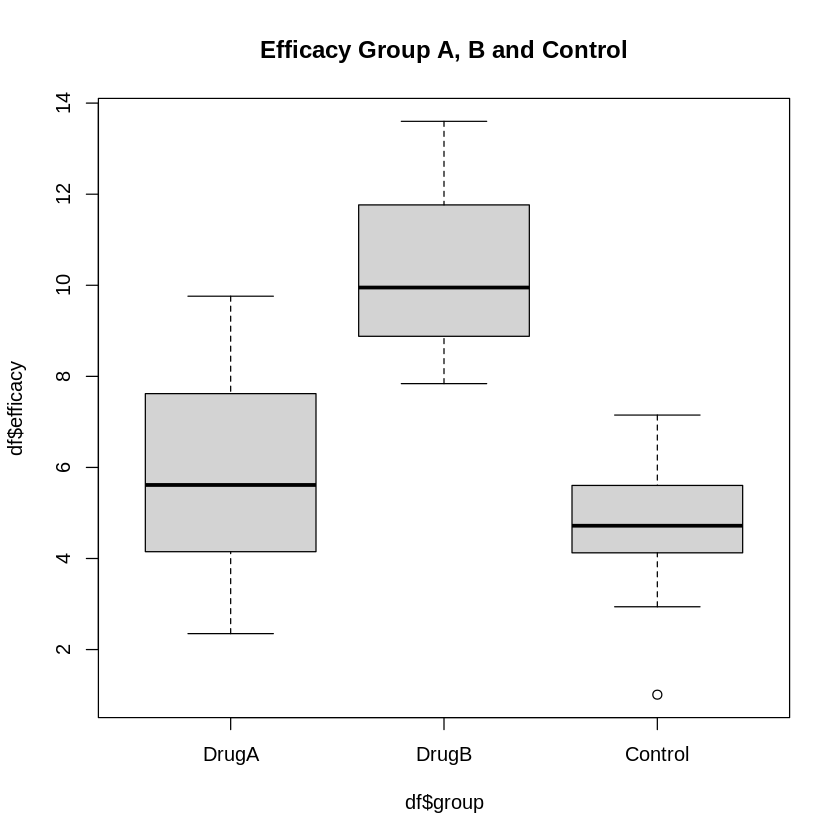

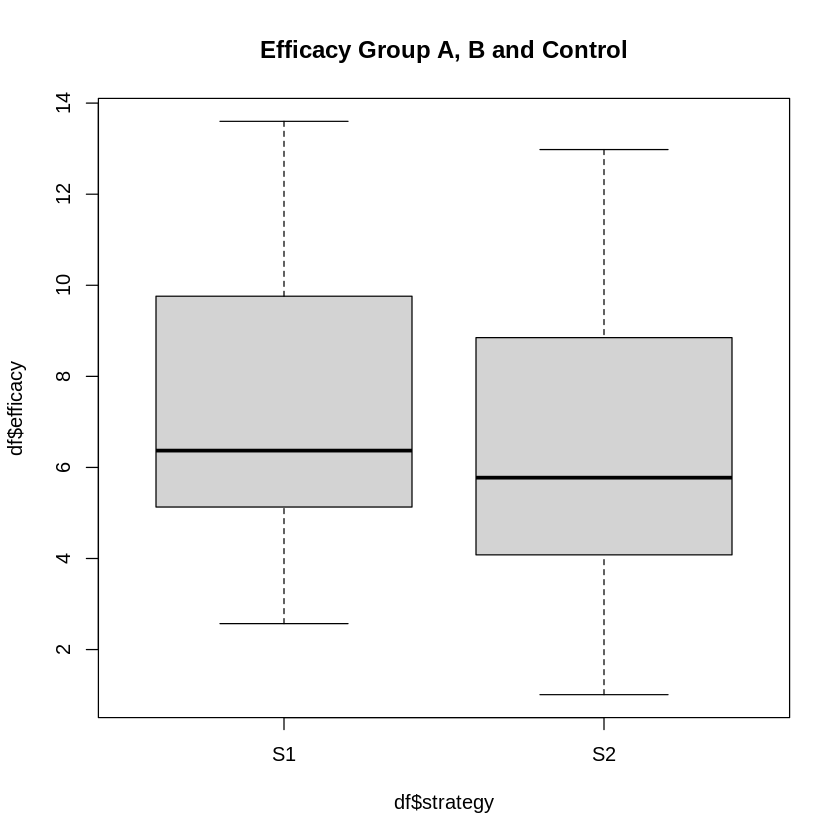

In [197]:
print("Mean then SD of A, B, Control")
mean_A = mean(g_drugA)
sd_A = sd(g_drugA)
mean_B = mean(g_drugB)
sd_B = sd(g_drugB)
mean_control = mean(g_control)
sd_control = sd(g_control)

cat(mean_A , sd_A, mean_B , sd_B ,mean_control , sd_control)

boxplot(df$efficacy ~ df$group,  data=data, main="Efficacy Group A, B and Control")
boxplot(df$efficacy ~ df$strategy,  data=data, main="Efficacy Group A, B and Control")

Shapiro-Wilk and Bartlett Tests

In [198]:
shapiro.test(df$efficacy)


	Shapiro-Wilk normality test

data:  df$efficacy
W = 0.95854, p-value = 0.008522


In [199]:
#wrt groups (strategy also included)

bartlett.test(df$efficacy ~ df$group, data=df)
#bartlett.test(df$efficacy ~ df$strategy, data=df)


	Bartlett test of homogeneity of variances

data:  df$efficacy by df$group
Bartlett's K-squared = 7.3837, df = 2, p-value = 0.02493


Conducting ANOVA: (imo group then strategy as comment)

In [200]:
model_1way = aov(df$efficacy ~ df$group, data=df)
summary(model_1way)    #interpret
#model_1way_strategy = aov()

            Df Sum Sq Mean Sq F value Pr(>F)    
df$group     2  474.1  237.07   79.43 <2e-16 ***
Residuals   81  241.8    2.98                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual Plots to test ANOVA Assumptions

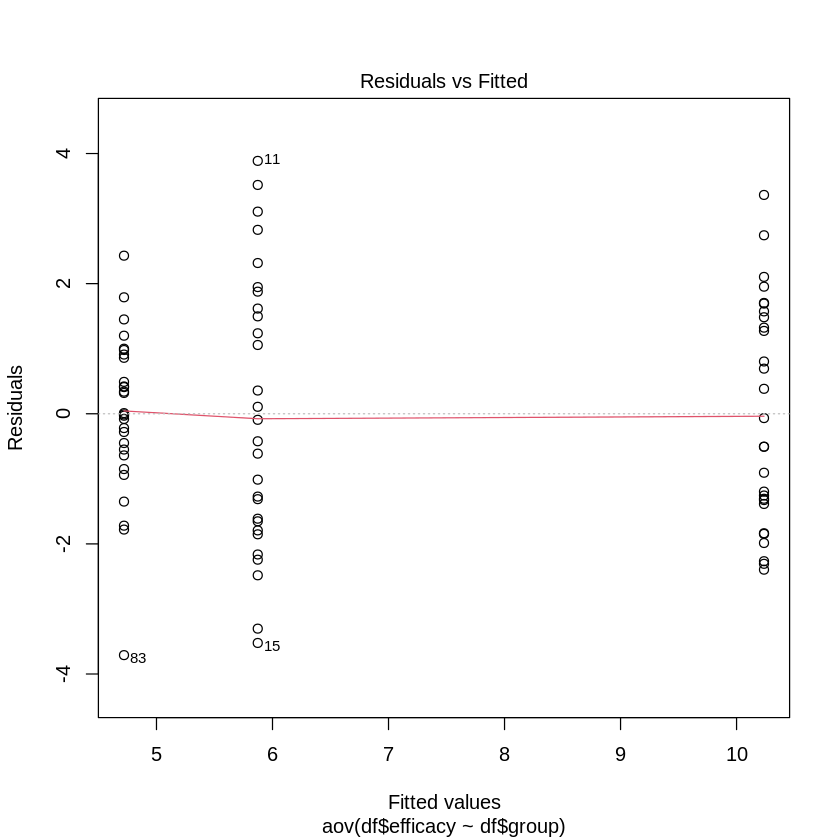

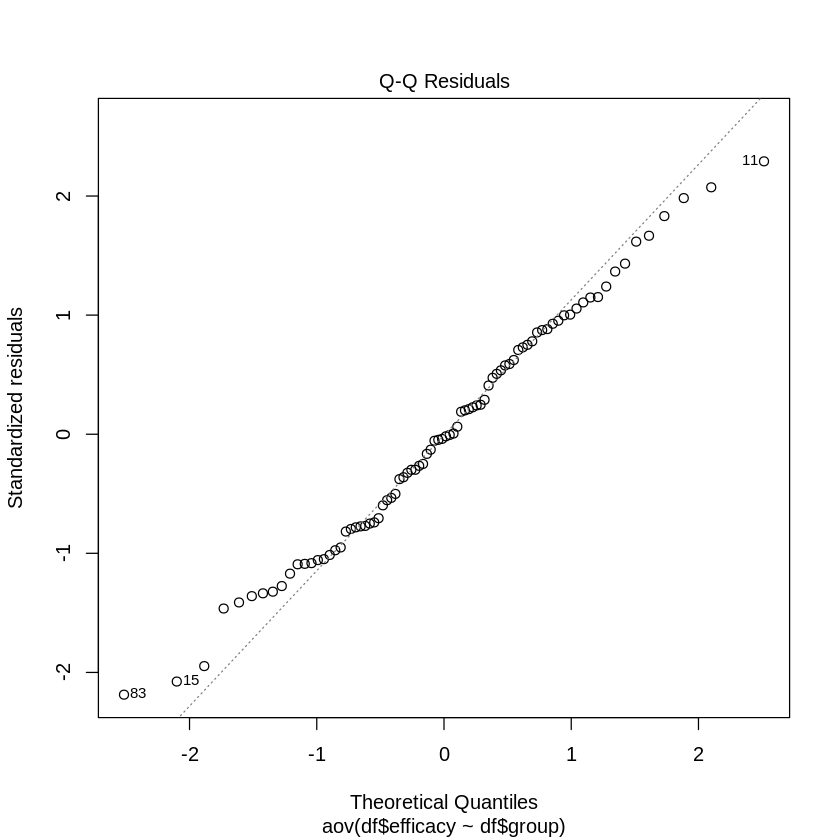

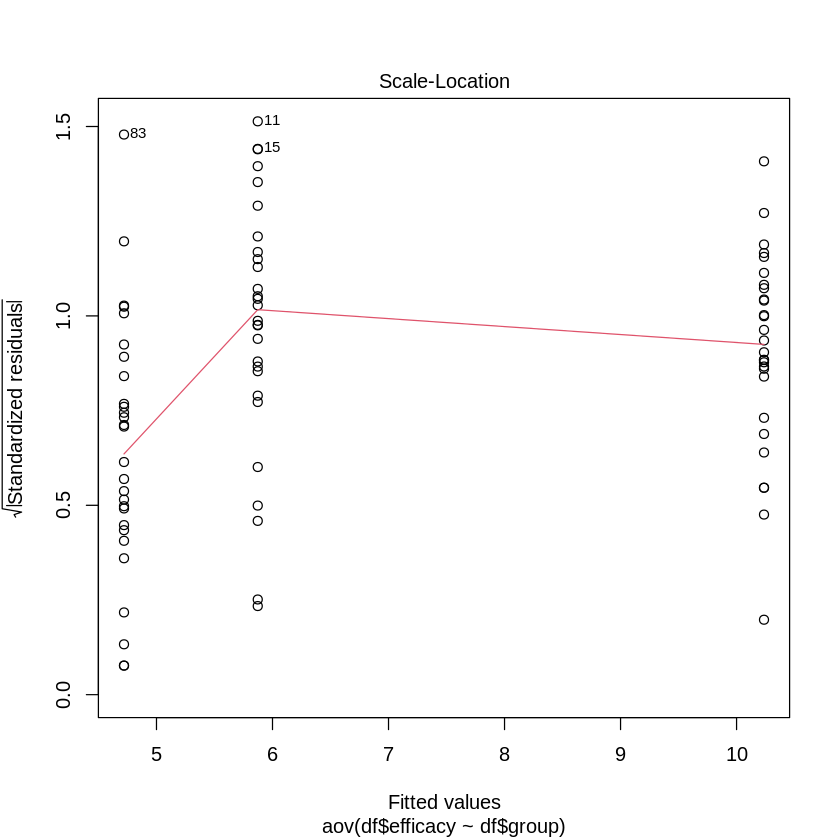

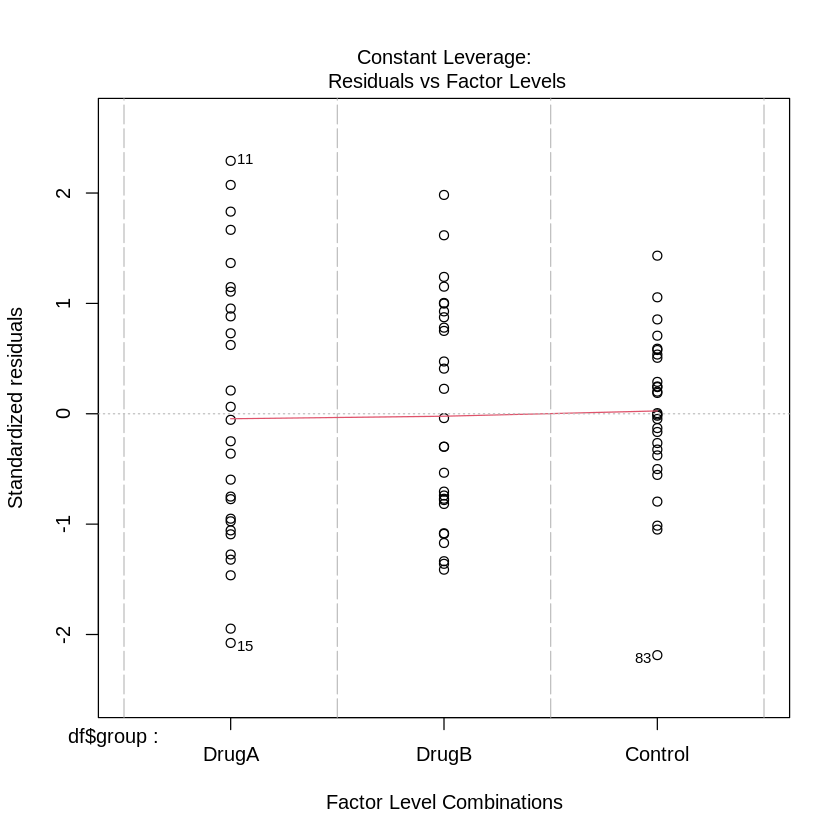

In [201]:
#equality of population variances
plot(model_1way)

Interaction Plot

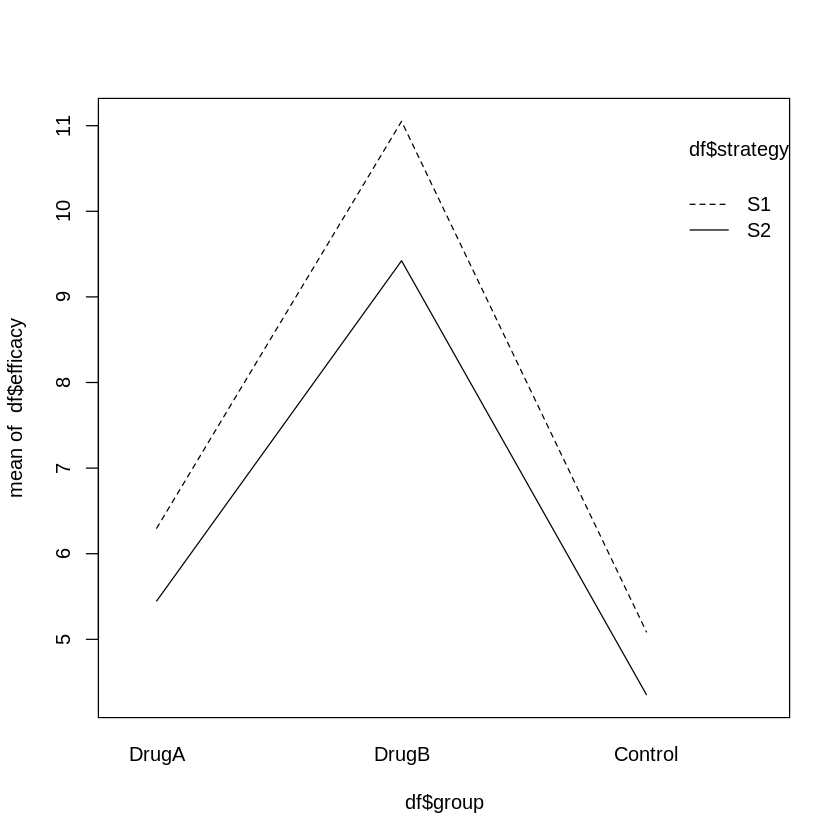

In [202]:
interaction.plot(df$group, df$strategy, df$efficacy)

No interaction (according to this plot): the additive model will suffice.

## 2. Hypothesis Testing (Two-Way ANOVA)

Test for significance among:

1.   Treatment groups (1 way)
2.   Strategies (1 way)
3.   A combination (2 way)

The associated hypotheses, in the same order:

1.   Do the drugs or lack of have a significant effect on the patient
2.   Does the strategy of giving thedrug affect its efficacy.
3.   ...


In [210]:
#grand mean, sum of all squared obs, nrows

a = 3
n = nrow(data)/2
N = a*b*n

class(data)

#keep data numerical
num_data = data[,c(2 ,3, 4)]
group_means = colMeans(num_data)
grand_mean = mean(as.matrix(num_data))

SS_T = sum(( num_data - grand_mean) ^2)

SS_B = n*sum( (group_means - grand_mean)^2)*2    #2 groups

SS_E = sum((t(num_data) - group_means) ^2)

#check equality
all.equal(SS_T,SS_B+SS_E)

MS_B = SS_B / (a - 1)
MS_E = SS_E / (N - a)

F = MS_B / MS_E
P = 1 - pf(F, a-1, N-a)

#table
table = data.frame(row.names=c("Between groups", "Residual", "Total"),
                   dof=c(a-1,N-a,N-1),
                   SS=c(SS_B,SS_E,SS_T),
                   MS=c(MS_B,MS_E,NA),
                   F=c(F,NA,NA),
                   P=c(P,NA,NA)
                  )
round(table, 3)

a

[1] "data.frame"

[1] TRUE

,dof,SS,MS,F,P
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Between groups,2,474.141,237.070,79.431,0
Residual,81,241.753,2.985,NA,NA
Total,83,715.894,NA,NA,NA


[1] 3

In [204]:
round(anova(model_1way), 3)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
df$group,2,474.141,237.070,79.431,0
Residuals,81,241.753,2.985,NA,NA


## **FILL WITH STRATEGY TEST**

In [252]:
a = 3
b=2    #these are our blocks (strategies)
n=nrow(data)/2
N = a*b*n
n_per_block = length(strat_df)

#filter by strategy
strat1_eff = df[df$strategy == 'S1',]$efficacy
strat2_eff = df[df$strategy == 'S2',]$efficacy
#attempting to make strat df so I can easily calculate
#groups will align
strat_df = cbind(strat1_eff, strat2_eff)
head(strat_df)
length(strat_df)

block_means = colMeans(strat_df)
SS_B_block = n_per_block * sum((block_means - grand_mean)^2) * 2
#SS_E_block = sum(t())
SS_T_block = sum((strat_df - grand_mean)^2)
SS_E_block = SS_T_block - SS_B_block

#check equality
all.equal(SS_T_block,SS_B_block+SS_E_block)

strat1_eff,strat2_eff
8.98,2.35
5.78,3.71
6.93,4.60
5.45,8.70
4.86,4.08
5.26,4.22


[1] 84

[1] TRUE

In [247]:
model_1way_strat = aov(df$efficacy ~ df$strategy, data = df)
round(anova(model_1way_strat), 3)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
df$strategy,1,24.064,24.064,2.852,0.095
Residuals,82,691.830,8.437,NA,NA


## 3. Planned Linear Contrasts

## 4. Clinical Interpretation

**Conclusions:**

-

-

-

---

## Memo

- 10% of marks are allocated for clarity of R code and the overall report quality.
- Verify your work. Restart the kernel and re-run the whole notebook.
- Do not use any local files. The data should be read directly from the github link.
- Make a pdf copy of this notebook and submit together with the notebook.
- If you've used Google Colab to complete this assignment, post a link to your Google Colab notebook in the comments section.

---